In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Delivery_Logistics.csv")
df.shape

(25000, 15)

In [3]:
df['delayed'].value_counts()

delayed
no     18331
yes     6669
Name: count, dtype: int64

In [4]:
df['delivery_status'].value_counts()

delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64

In [5]:
df['delayed'].value_counts(normalize=True) * 100

delayed
no     73.324
yes    26.676
Name: proportion, dtype: float64

In [6]:
df['delivery_status'].value_counts(normalize=True) * 100

delivery_status
delivered    73.324
delayed      21.364
failed        5.312
Name: proportion, dtype: float64

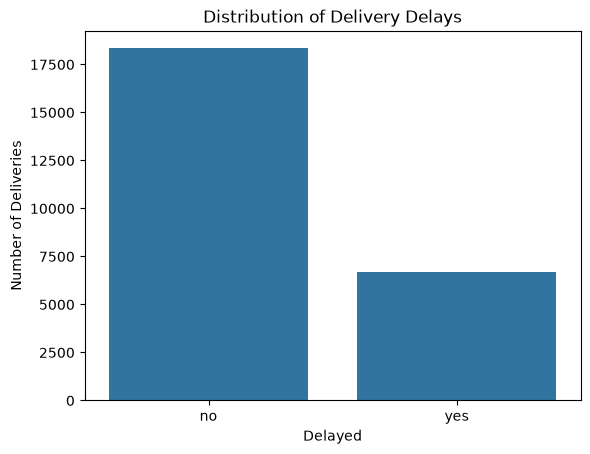

In [7]:
sns.countplot(data=df, x='delayed')

plt.title('Distribution of Delivery Delays')
plt.xlabel('Delayed')
plt.ylabel('Number of Deliveries')

plt.show()

In [8]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,3.666000,864.944579
std,7212.732314,86.409745,14.368663,1.149964,435.712593
min,250.990000,3.600000,0.670000,1.000000,95.667400
25%,6250.750000,75.900000,12.680000,3.000000,490.800000
50%,12500.500000,151.000000,25.145000,4.000000,867.535000
75%,18750.250000,224.900000,37.660000,5.000000,1237.910000
max,24750.010000,297.100000,49.520000,5.000000,1632.720600


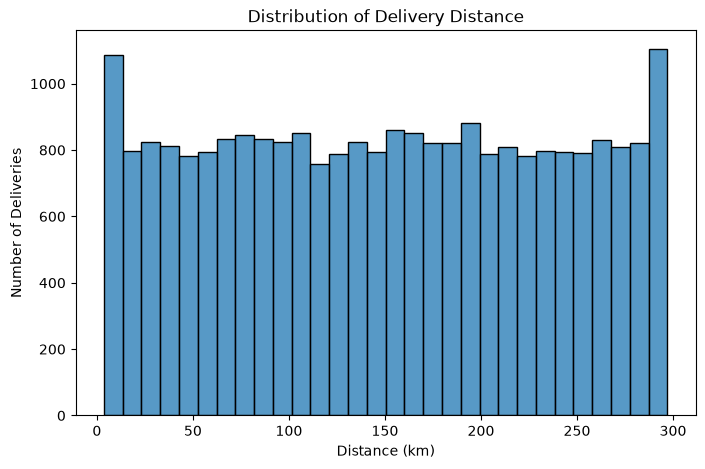

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='distance_km',
    bins=30
)

plt.title("Distribution of Delivery Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Deliveries")

plt.show()

In [10]:
df['distance_km'].skew()

np.float64(0.0018829553566453861)

In [11]:
numerical_cols = [
    'distance_km',
    'package_weight_kg',
    'delivery_rating',
    'delivery_cost'
]

df[numerical_cols].skew()

distance_km          0.001883
package_weight_kg   -0.002607
delivery_rating     -0.473126
delivery_cost        0.001108
dtype: float64

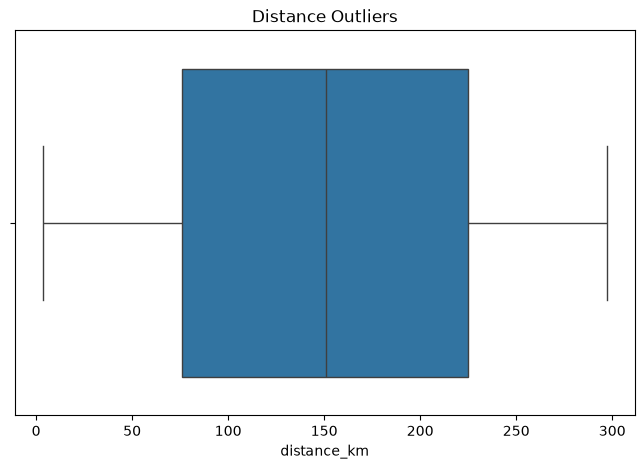

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='distance_km'
)

plt.title("Distance Outliers")

plt.show()

In [13]:
pd.crosstab(
    df['weather_condition'],
    df['delayed'],
    normalize='index'
)*100

delayed,no,yes
weather_condition,,
clear,82.565470,17.434530
cold,83.982684,16.017316
foggy,69.684759,30.315241
hot,82.881356,17.118644
rainy,62.646847,37.353153
stormy,58.551691,41.448309


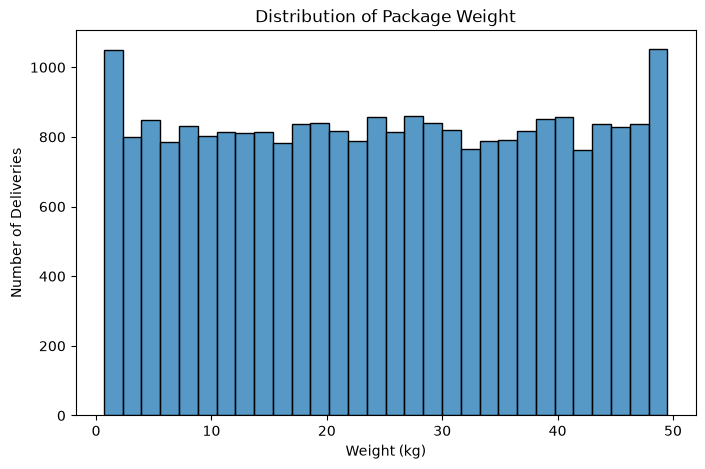

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='package_weight_kg',
    bins=30
)

plt.title("Distribution of Package Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Deliveries")

plt.show()

In [15]:
df['package_weight_kg'].describe()

count    25000.000000
mean        25.145898
std         14.368663
min          0.670000
25%         12.680000
50%         25.145000
75%         37.660000
max         49.520000
Name: package_weight_kg, dtype: float64

In [16]:
df['package_weight_kg'].skew()

np.float64(-0.002606811087682549)

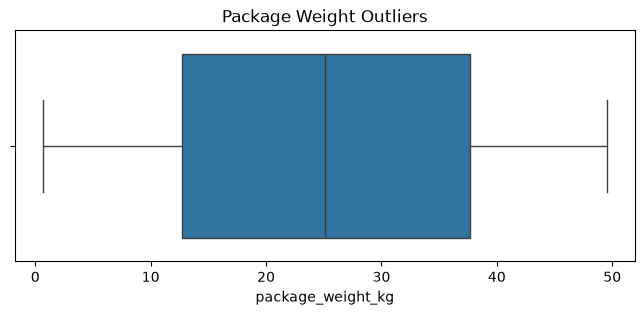

In [17]:
plt.figure(figsize=(8,3))

sns.boxplot(
    data=df,
    x='package_weight_kg'
)

plt.title("Package Weight Outliers")

plt.show()

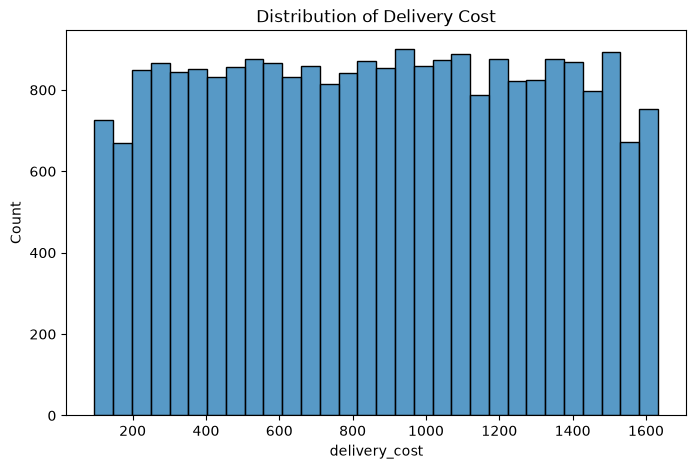

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='delivery_cost',
    bins=30
)

plt.title("Distribution of Delivery Cost")

plt.show()

In [19]:
df['delivery_cost'].skew()

np.float64(0.0011078731684383153)

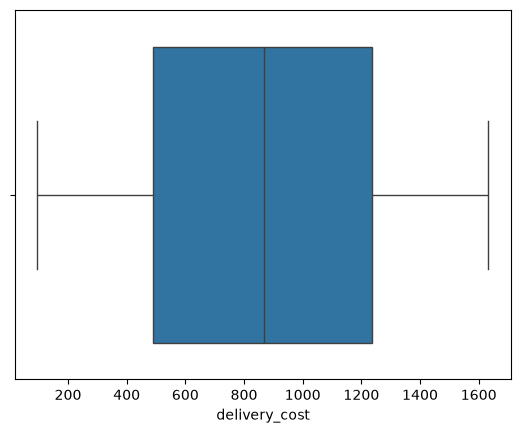

In [20]:
sns.boxplot(
    data=df,
    x='delivery_cost'
)

plt.show()

## Numerical Feature Summary

### distance_km
- Distribution is approximately uniform/balanced.
- Skewness is close to zero.
- No significant outliers detected.

### package_weight_kg
- Distribution is balanced.
- Mean and median are almost identical.
- No significant outliers detected.


### delivery_cost
- Distribution is balanced.
- Skewness is close to zero.
- No significant outliers detected.

### delivery_rating
- Removed from modeling consideration because it is generated after delivery completion and may cause data leakage.

In [21]:
for col in df:
    categorical_cols = [
    'delivery_partner',
    'package_type',
    'vehicle_type',
    'delivery_mode',
    'region',
    'weather_condition'
]
    

In [22]:
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print("----------------")

delivery_partner
<StringArray>
[       'delhivery',       'xpressbees',        'shadowfax',
              'dhl', 'amazon logistics',        'blue dart',
            'fedex',     'ecom express',            'ekart']
Length: 9, dtype: str
----------------
package_type
<StringArray>
['automobile parts',        'cosmetics',        'groceries',
      'electronics',         'clothing',        'documents',
    'fragile items',         'pharmacy',        'furniture']
Length: 9, dtype: str
----------------
vehicle_type
<StringArray>
['bike', 'ev van', 'truck', 'van', 'ev bike', 'scooter']
Length: 6, dtype: str
----------------
delivery_mode
<StringArray>
['same day', 'express', 'two day', 'standard']
Length: 4, dtype: str
----------------
region
<StringArray>
['west', 'central', 'east', 'north', 'south']
Length: 5, dtype: str
----------------
weather_condition
<StringArray>
['clear', 'cold', 'rainy', 'foggy', 'hot', 'stormy']
Length: 6, dtype: str
----------------


In [23]:
df['weather_condition'].value_counts()

weather_condition
foggy     4219
stormy    4198
rainy     4171
cold      4158
hot       4130
clear     4124
Name: count, dtype: int64

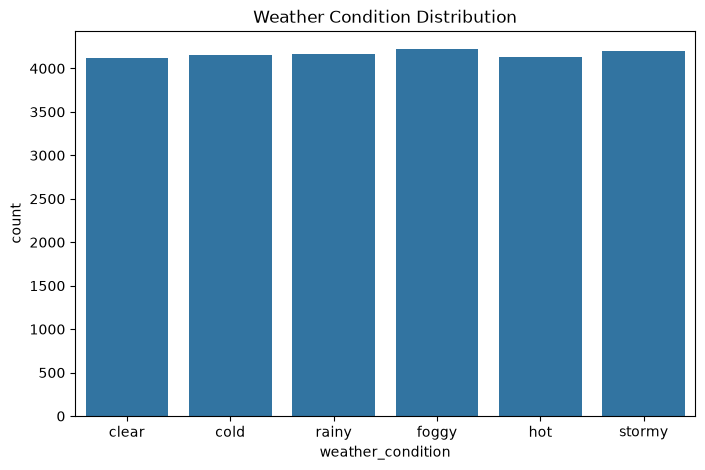

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='weather_condition'
)

plt.title("Weather Condition Distribution")

plt.show()

In [25]:
pd.crosstab(
    df['weather_condition'],
    df['delayed'],
    normalize='index'
)*100

delayed,no,yes
weather_condition,,
clear,82.565470,17.434530
cold,83.982684,16.017316
foggy,69.684759,30.315241
hot,82.881356,17.118644
rainy,62.646847,37.353153
stormy,58.551691,41.448309


In [26]:
df['vehicle_type'].value_counts()

vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

In [27]:
pd.crosstab(
    df['vehicle_type'],
    df['delayed'],
    normalize='index'
)*100

delayed,no,yes
vehicle_type,,
bike,72.956731,27.043269
ev bike,73.565671,26.434329
ev van,73.372206,26.627794
scooter,73.862003,26.137997
truck,72.955368,27.044632
van,73.226654,26.773346


In [28]:
pd.crosstab(
    [df['vehicle_type'], df['weather_condition']],
    df['delayed'],
    normalize='index'
)*100

delayed                                no        yes
vehicle_type weather_condition                      
bike         clear              83.938547  16.061453
             cold               81.638847  18.361153
             foggy              68.829337  31.170663
             hot                82.639885  17.360115
             rainy              60.907760  39.092240
             stormy             59.770115  40.229885
ev bike      clear              80.945122  19.054878
             cold               85.227273  14.772727
             foggy              70.027624  29.972376
             hot                84.729730  15.270270
             rainy              61.118881  38.881119
             stormy             59.057437  40.942563
ev van       clear              82.209469  17.790531
             cold               84.450785  15.549215
             foggy              69.972067  30.027933
             hot                80.521472  19.478528
             rainy              64.188164  35.811836
             stormy             58.755427  41.244573
scooter      clear              85.059172  14.940828
             cold               84.682081  15.317919
             foggy              71.324600  28.675400
             hot                82.898551  17.101449
             rainy              63.532764  36.467236
             stormy             56.946355  43.053645
truck        clear              81.107955  18.892045
             cold               84.110787  15.889213
             foggy              68.869310  31.130690
             hot                81.313869  18.686131
             rainy              64.553314  35.446686
             stormy             57.841727  42.158273
van          clear              82.074074  17.925926
             cold               83.659218  16.340782
             foggy              69.088319  30.911681
             hot                84.984985  15.015015
             rainy              61.699164  38.300836
             stormy             59.014085  40.985915

In [29]:
pd.crosstab(
    df['delivery_partner'],
    df['delayed'],
    normalize='index'
)*100

delayed,no,yes
delivery_partner,,
amazon logistics,72.777573,27.222427
blue dart,73.052180,26.947820
delhivery,75.197416,24.802584
dhl,73.661670,26.338330
ecom express,73.365173,26.634827
ekart,72.581221,27.418779
fedex,74.840312,25.159688
shadowfax,72.697368,27.302632
xpressbees,71.726822,28.273178


In [30]:
df['delivery_mode'].value_counts()

delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

In [31]:
pd.crosstab(
    df['delivery_mode'],
    df['delayed'],
    normalize='index'
)*100

delayed,no,yes
delivery_mode,,
express,26.215306,73.784694
same day,67.462972,32.537028
standard,100.000000,0.000000
two day,99.571565,0.428435


In [32]:
pd.crosstab(
    df['delivery_mode'],
    df['delayed']
)

delayed,no,yes
delivery_mode,,
express,1634,4599
same day,4236,2043
standard,6186,0
two day,6275,27


In [33]:
pd.crosstab(
    df['delivery_mode'],
    df['delivery_status'],
    normalize='index'
)*100

delivery_status,delayed,delivered,failed
delivery_mode,,,
express,59.361463,26.215306,14.423231
same day,25.784361,67.462972,6.752668
standard,0.000000,100.000000,0.000000
two day,0.349096,99.571565,0.079340


## Delivery Mode Analysis

Delivery mode shows a very strong relationship with delivery delays.

Express deliveries have a significantly higher delay rate (73.8%), while standard and two-day deliveries show almost no delays.

Because delivery mode is available before delivery starts, it is a valid prediction feature. However, the unusually strong separation suggests possible dataset generation bias and should be monitored during model evaluation.

In [34]:
df['region'].value_counts()

region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64

In [35]:
pd.crosstab(
    df['region'],
    df['delayed'],
    normalize='index'
)*100

delayed,no,yes
region,,
central,72.747036,27.252964
east,74.202074,25.797926
north,73.428976,26.571024
south,73.216797,26.783203
west,73.052012,26.947988


In [36]:
df['package_type'].value_counts()

package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64

In [37]:
pd.crosstab(
    df['package_type'],
    df['delayed'],
    normalize='index'
)*100

delayed,no,yes
package_type,,
automobile parts,73.810376,26.189624
clothing,73.906758,26.093242
cosmetics,72.959184,27.040816
documents,72.834225,27.165775
electronics,72.815186,27.184814
fragile items,73.349719,26.650281
furniture,75.236708,24.763292
groceries,72.558485,27.441515
pharmacy,72.455516,27.544484


## Package Type Analysis

Package type shows only minor differences in delay rates. All categories have delay percentages around 25-28%, suggesting that package type alone is not a strong predictor of delivery delays in this dataset.

In [38]:
df.groupby('delayed')['distance_km'].describe()

,count,mean,std,min,25%,50%,75%,max
delayed,,,,,,,,
no,18331.0,141.302826,85.422587,3.6,67.2,137.0,212.8,297.1
yes,6669.0,175.369441,84.160434,3.6,108.9,186.3,249.1,297.1


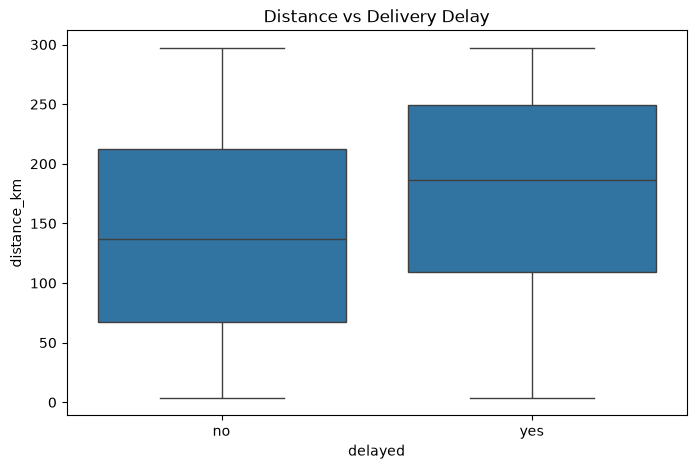

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='delayed',
    y='distance_km'
)

plt.title("Distance vs Delivery Delay")

plt.show()

In [40]:
df.groupby('delayed')['package_weight_kg'].describe()

,count,mean,std,min,25%,50%,75%,max
delayed,,,,,,,,
no,18331.0,25.137559,14.344966,0.67,12.73,25.09,37.64,49.52
yes,6669.0,25.168817,14.434651,0.67,12.51,25.30,37.73,49.52


In [41]:
df.groupby('delayed')['delivery_cost'].describe()

,count,mean,std,min,25%,50%,75%,max
delayed,,,,,,,,
no,18331.0,809.752933,424.656468,95.6674,444.945,791.76,1165.165,1632.7206
yes,6669.0,1016.649192,429.687191,95.6674,677.880,1075.06,1388.970,1632.7206


In [42]:
df.groupby('delayed')['distance_km'].describe()

,count,mean,std,min,25%,50%,75%,max
delayed,,,,,,,,
no,18331.0,141.302826,85.422587,3.6,67.2,137.0,212.8,297.1
yes,6669.0,175.369441,84.160434,3.6,108.9,186.3,249.1,297.1


In [43]:
numeric_cols = [
    'distance_km',
    'package_weight_kg',
    'delivery_cost'
]

df[numeric_cols].corr()

,distance_km,package_weight_kg,delivery_cost
distance_km,1.000000,0.002311,0.990772
package_weight_kg,0.002311,1.000000,0.099479
delivery_cost,0.990772,0.099479,1.000000


In [47]:
df['delivery_id'].duplicated().sum()

np.int64(498)

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df[['delivery_time_hours', 'expected_time_hours']].head(10)

,delivery_time_hours,expected_time_hours
0,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008
1,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003
2,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016
3,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008
4,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016
5,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000002
6,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008
7,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000008
8,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000008
9,1970-01-01 00:00:00.000000003,1970-01-01 00:00:00.000000008


In [50]:
df[['delivery_time_hours', 'expected_time_hours']].dtypes

delivery_time_hours    str
expected_time_hours    str
dtype: object

In [51]:
df[df['delivery_id'].duplicated(keep=False)].sort_values('delivery_id').head(10)

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600
5,250.99,amazon logistics,documents,ev bike,express,west,rainy,48.4,33.15,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000002,yes,delayed,3,391.4500
6,250.99,delhivery,groceries,scooter,same day,central,clear,198.3,43.79,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1222.8700
7,250.99,xpressbees,fragile items,van,same day,north,cold,114.6,42.63,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000008,no,delivered,3,800.8900
8,250.99,blue dart,clothing,van,same day,south,hot,142.4,14.06,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000008,no,delivered,5,854.1800
9,250.99,delhivery,pharmacy,truck,same day,east,foggy,47.1,29.28,1970-01-01 00:00:00.000000003,1970-01-01 00:00:00.000000008,no,delivered,5,423.3400


In [52]:
df['delivery_id'].value_counts().head(10)

delivery_id
250.99      250
24750.01    250
251.00        1
252.00        1
253.00        1
254.00        1
255.00        1
256.00        1
257.00        1
258.00        1
Name: count, dtype: int64

In [53]:
df['delivery_id'].nunique()

24502

In [54]:
df['delivery_id'].describe()

count    25000.000000
mean     12500.500000
std       7212.732314
min        250.990000
25%       6250.750000
50%      12500.500000
75%      18750.250000
max      24750.010000
Name: delivery_id, dtype: float64

In [55]:
df = df.drop(columns=['delivery_id'])

In [56]:
df[['delivery_time_hours', 'expected_time_hours']].head(20)

,delivery_time_hours,expected_time_hours
0,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008
1,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003
2,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016
3,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008
4,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016
5,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000002
6,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008
7,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000008
8,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000008
9,1970-01-01 00:00:00.000000003,1970-01-01 00:00:00.000000008


In [57]:
df[['delivery_time_hours', 'expected_time_hours']].tail(20)

,delivery_time_hours,expected_time_hours
24980,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000004
24981,1970-01-01 00:00:00.000000003,1970-01-01 00:00:00.000000002
24982,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008
24983,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000006
24984,1970-01-01 00:00:00.000000003,1970-01-01 00:00:00.000000008
24985,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000008
24986,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000024
24987,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003
24988,1970-01-01 00:00:00.000000012,1970-01-01 00:00:00.000000008
24989,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000007


In [58]:
df[['delivery_time_hours', 'expected_time_hours']].nunique()

delivery_time_hours    20
expected_time_hours     9
dtype: int64

In [61]:
df['expected_time_hours'].unique()

<StringArray>
['1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000003',
 '1970-01-01 00:00:00.000000016', '1970-01-01 00:00:00.000000002',
 '1970-01-01 00:00:00.000000006', '1970-01-01 00:00:00.000000024',
 '1970-01-01 00:00:00.000000007', '1970-01-01 00:00:00.000000004',
 '1970-01-01 00:00:00.000000005']
Length: 9, dtype: str

In [62]:
df['delivery_time_hours'].unique()

<StringArray>
['1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000002',
 '1970-01-01 00:00:00.000000010', '1970-01-01 00:00:00.000000006',
 '1970-01-01 00:00:00.000000009', '1970-01-01 00:00:00.000000004',
 '1970-01-01 00:00:00.000000005', '1970-01-01 00:00:00.000000003',
 '1970-01-01 00:00:00.000000012', '1970-01-01 00:00:00.000000011',
 '1970-01-01 00:00:00.000000007', '1970-01-01 00:00:00.000000013',
 '1970-01-01 00:00:00.000000000', '1970-01-01 00:00:00.000000001',
 '1970-01-01 00:00:00.000000014', '1970-01-01 00:00:00.000000016',
 '1970-01-01 00:00:00.000000015', '1970-01-01 00:00:00.000000017',
 '1970-01-01 00:00:00.000000018', '1970-01-01 00:00:00.000000019']
Length: 20, dtype: str

In [63]:
df['delivery_time_temp'] = (
    df['delivery_time_hours']
    .str.extract(r'(\d+)$')[0]
    .astype(int)
)

df['expected_time_temp'] = (
    df['expected_time_hours']
    .str.extract(r'(\d+)$')[0]
    .astype(int)
)

In [64]:
df[['delivery_time_temp', 'expected_time_temp', 'delayed']].head(10)

,delivery_time_temp,expected_time_temp,delayed
0,8,8,no
1,2,3,no
2,10,16,no
3,6,8,no
4,9,16,no
5,4,2,yes
6,6,8,no
7,4,8,no
8,5,8,no
9,3,8,no


In [65]:
pd.crosstab(
    df['expected_time_temp'],
    df['delayed'],
    normalize='index'
) * 100

delayed,no,yes
expected_time_temp,,
2,34.187192,65.812808
3,31.778426,68.221574
4,25.650916,74.349084
5,21.203704,78.796296
6,23.593287,76.406713
7,21.313035,78.686965
8,67.408939,32.591061
16,99.571565,0.428435
24,100.000000,0.000000


In [66]:
df.groupby('expected_time_temp')['distance_km'].describe()

,count,mean,std,min,25%,50%,75%,max
expected_time_temp,,,,,,,,
2,1015.0,25.423547,13.877454,3.6,13.250,25.4,37.5,49.7
3,1029.0,74.509621,14.377695,49.8,61.900,74.8,86.4,99.7
4,1037.0,125.246384,14.675682,99.8,112.900,124.9,138.1,149.7
5,1080.0,175.129722,14.425962,149.8,162.875,175.1,187.8,199.7
6,1013.0,224.816091,14.308988,199.8,212.600,224.5,237.1,249.7
7,1051.0,275.252046,14.226481,249.8,262.800,275.6,287.9,297.1
8,6287.0,151.346938,86.905292,3.6,77.400,152.6,225.5,297.1
16,6302.0,150.811203,86.644475,3.6,75.500,151.8,226.5,297.1
24,6186.0,148.610734,85.760032,3.6,74.800,147.0,222.5,297.1


In [67]:
pd.crosstab(
    df['delivery_mode'],
    df['expected_time_temp'],
    normalize='index'
) * 100

expected_time_temp,2,3,4,5,6,7,8,16,24
delivery_mode,,,,,,,,,
express,16.284293,16.508904,16.637253,17.32713,16.252206,16.861864,0.128349,0.0,0.0
same day,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,100.000000,0.0,0.0
standard,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,100.0
two day,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,100.0,0.0


In [68]:
pd.crosstab(
    df['delivery_status'],
    df['delayed'],
    normalize='index'
) * 100

delayed,no,yes
delivery_status,,
delayed,0.0,100.0
delivered,100.0,0.0
failed,0.0,100.0


In [69]:
df_model = df.drop(columns=[
    'delivery_time_hours',
    'delivery_status',
    'delivery_rating'
])

# EDA Summary

## Dataset
- 25,000 observations and 15 original columns.
- No missing values were found.
- No completely duplicated rows were found.
- `delivery_id` contains repeated values and is not suitable as a predictive feature.

## Target
- `delayed` contains:
  - No: 73.324%
  - Yes: 26.676%
- The target is moderately imbalanced.

## Numerical Features
- `distance_km` shows a noticeable difference between delayed and non-delayed deliveries.
- `package_weight_kg` shows very little difference between the two target groups.
- `delivery_cost` shows a noticeable difference between delayed and non-delayed deliveries.
- `distance_km` and `delivery_cost` have a very strong positive correlation (0.9908).

## Categorical Features
- `weather_condition` shows differences in delay rates, particularly for rainy and stormy conditions.
- `vehicle_type`, `delivery_partner`, `region`, and `package_type` show relatively small differences in delay rates.
- `delivery_mode` shows a very strong relationship with `delayed`.

## Expected Delivery Time
- `expected_time_hours` has only 9 unique values.
- It has a strong relationship with `delivery_mode`.
- For expected times from 2 to 7 hours, the expected time also corresponds to progressively larger distance ranges.
- This suggests that `expected_time_hours` contains information overlapping with `delivery_mode` and `distance_km`.

## Leakage / Outcome Variables
The following variables should not be used as prediction features:

- `delivery_time_hours`: represents information available after/during completion of the delivery and may cause target leakage.
- `delivery_status`: directly corresponds to the `delayed` target.
- `delivery_rating`: represents post-delivery information.

## Initial Feature Decisions

Potential model features:
- `delivery_partner`
- `package_type`
- `vehicle_type`
- `delivery_mode`
- `region`
- `weather_condition`
- `distance_km`
- `package_weight_kg`
- `expected_time_hours`
- `delivery_cost`

Target:
- `delayed`

Excluded:
- `delivery_id`
- `delivery_time_hours`
- `delivery_status`
- `delivery_rating`
